# Laboratorio integrador: analizador de tendencias en noticias argentinas

**Duración estimada:** 1 hora

## Desafío
Vas a construir un sistema en Python que extraiga noticias de la web y las procese con `spaCy` para identificar entidades, verbos frecuentes, palabras clave y visualizaciones básicas.

## Resultados esperados
Al finalizar este laboratorio, vas a poder:
- extraer texto desde una URL periodística;
- encapsular análisis lingüístico en una clase reutilizable;
- generar visualizaciones a partir del texto procesado;
- integrar varias piezas en un pipeline simple de análisis de noticias.

## Modalidad de trabajo: pair programming con IA
En esta cátedra, `pair programming con IA` significa que la unidad de trabajo está formada por vos y un asistente de IA.

La IA puede ayudarte a:
- proponer estrategias;
- explicarte errores o mensajes del entorno;
- sugerir casos de prueba;
- comparar enfoques posibles;
- auditar código que ya escribiste.

La IA no reemplaza tu pensamiento. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu criterio.

## Bitácora breve de interacción con IA
Completá al menos una entrada por cada parte del laboratorio.

**Plantilla sugerida**
- Objetivo de la consulta.
- Prompt o pedido que hiciste.
- Qué te devolvió la IA.
- Qué conservaste.
- Qué corregiste o descartaste.
- Qué aprendiste del intercambio.


In [27]:
# Instalamos las librerías necesarias en modo silencioso (-q)
!pip install spacy trafilatura pandas matplotlib wordcloud plotly -q
!python -m spacy download es_core_news_lg -q



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install "lxml[html-clean]" -q
!pip install nbformat -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Importación de librerías
import spacy
import trafilatura
import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.graph_objects as go

nlp = spacy.load("es_core_news_lg")
print("Modelo y librerías cargadas.")


Modelo y librerías cargadas.


## Parte 1: extracción de noticias (15 minutos)

**Objetivo:** construir una función que reciba una URL y devuelva un diccionario con el texto limpio de la noticia.

**Antes de escribir código, hace esta consulta a la IA:**
- Pedile dos estrategias posibles para descargar y extraer el contenido principal de una página.
- Elegí una y explicá por qué.

**Recordatorio:** si la IA te propone código, revisalo antes de incorporarlo.


In [30]:
#Se consultó a la IA, la misma recomendó un enfoque con Trafilatura y con BeautifulSoup, se optó por Trafilatura por ser más específico para la extracción de contenido de noticias y por tener las dependencias necesarias ya instaladas.

def extraer_noticia(url):
    """
    Extrae el contenido principal de una noticia desde una URL.
    """
    try:
        # PASO 1: descargar el HTML de la página con trafilatura
        descargado = trafilatura.fetch_url(url)

        # PASO 2: extraer el texto principal a partir del HTML descargado
        texto = trafilatura.extract(descargado)

        if texto:
            return {
                'url': url,
                'texto': texto,
                'fecha_extraccion': datetime.now().strftime("%Y-%m-%d %H:%M")
            }

        print(f"Advertencia: no se pudo extraer texto de {url}")
        return None
    except Exception as e:
        print(f"Error procesando {url}: {e}")
        return None


# Reemplazá estas URLs por artículos reales cuando quieras probar la función.
urls_noticias = [
"https://www.lanacion.com.ar/politica/una-advertencia-que-sacudio-al-gobierno-nid18042026/",
"https://www.lanacion.com.ar/deportes/futbol/superclasico-los-puntajes-de-river-nid19042026/",
"https://www.lanacion.com.ar/deportes/futbol/los-festejos-intimos-de-boca-en-el-monumental-tras-la-victoria-sobre-river-por-1-a-0-nid19042026/"
]

# OPCIÓN 2: Guardar todos los resultados
noticias_extraidas = []
for url in urls_noticias:
    resultado = extraer_noticia(url)
    if resultado:
        noticias_extraidas.append(resultado)

print(f"\n✓ Se extrajeron {len(noticias_extraidas)} de {len(urls_noticias)} noticias")
print(noticias_extraidas)

# Sugerencia de prueba gradual:
# 1. Probá con una sola URL.
# 2. Verificá que el texto no sea None.
# 3. Recién después pasa a varias URLs.



✓ Se extrajeron 3 de 3 noticias
[{'url': 'https://www.lanacion.com.ar/politica/una-advertencia-que-sacudio-al-gobierno-nid18042026/', 'texto': "Una advertencia que sacudió al Gobierno\nEl ministro Caputo pidió un acuerdo urgente con los gobernadores para reanimar la economía, y generó ruido; el temblor en la Justicia por el arribo de Mahiques y la disputa por incidir en los pliegos\n- 13 minutos de lectura'\nHace casi tres semanas se produjo la discusión interna más importante de los últimos tiempos en la cúpula del Gobierno. Ocurrió el lunes 30 de marzo en la reunión de la mesa política. Fue el día en el que Luis Caputo reconoció que había tomado todas las medidas posibles para reanimar la economía y que el menú de opciones técnicas dentro del plan que impulsa se había agotado. “Ya tiré toda la carne al asador”, fue la frase que sintetizó su repaso, que incluyó desde el ajuste fiscal y el torniquete monetario, hasta el acuerdo con el FMI y la ayuda de Estados Unidos. Fue una expresió

## Parte 2: análisis de texto con spaCy (20 minutos)

**Objetivo:** encapsular el análisis en una clase `AnalizadorNoticia`.

**Consulta sugerida a la IA antes de completar los métodos:**
- Pedile un mapa de responsabilidades para la clase.
- Pedile criterios para distinguir personas, organizaciones y lugares a partir de `ent.label_`.
- Después compara esa propuesta con la documentación o con las salidas del modelo.


In [31]:
class AnalizadorNoticia:
    def __init__(self, texto, nlp_model):
        """
        Inicializa el analizador con un texto y un modelo de spaCy ya cargado.
        """
        self.texto_original = texto
        self.nlp = nlp_model

        # PASO 3: procesa el texto y guarda el objeto Doc en self.doc
        self.doc = self.nlp(self.texto_original)

    def obtener_entidades(self):
        """Devuelve un diccionario con entidades agrupadas por tipo."""
        entidades = {
            'PERSONAS': [],
            'ORGANIZACIONES': [],
            'LUGARES': [],
            'OTROS': []
        }

        for ent in self.doc.ents:
            if ent.label_ == 'PER':
                entidades['PERSONAS'].append(ent.text)
            elif ent.label_ == 'ORG':
                entidades['ORGANIZACIONES'].append(ent.text)
            elif ent.label_ == 'LOC':
                entidades['LUGARES'].append(ent.text)
            else:  
                entidades['OTROS'].append(ent.text)

        # PASO 4: itera sobre self.doc.ents y clasifica cada entidad.
        # Pista: revisa valores como 'PER', 'ORG', 'LOC' y 'MISC'.
        return entidades

    def obtener_verbos_principales(self, n=10):
        """Devuelve una lista de tuplas (verbo_lematizado, frecuencia)."""
        # PASO 5: filtra verbos, lematizalos y contalos con Counter.
        verbos = []

        for token in self.doc:
            if token.pos_ == 'VERB':
                verbos.append(token.lemma_)

        frecuencias = Counter(verbos)
        return frecuencias.most_common(n)

    def obtener_estadisticas(self):
        """Calcula estadísticas descriptivas básicas del texto."""
        # PASO 6: calcula estas métricas a partir de self.doc.
        total_tokens = len(self.doc)
        total_oraciones = len(list(self.doc.sents))
        palabras_unicas = len(set([token.text.lower() for token in self.doc if token.is_alpha]))

        if total_oraciones > 0:
            longitud_promedio_oracion = total_tokens / total_oraciones
        else:
            longitud_promedio_oracion = 0

        return {
            'total_tokens': total_tokens,
            'total_oraciones': total_oraciones,
            'palabras_unicas': palabras_unicas,
            'longitud_promedio_oracion': round(longitud_promedio_oracion, 2)
        }

    def extraer_frases_con_entidad(self, nombre_entidad):
        """Devuelve oraciones que contengan una entidad específica."""
        oraciones = []

        for sent in self.doc.sents:
            texto_sent = sent.text.lower()
            if nombre_entidad.lower() in texto_sent:
                oraciones.append(sent.text)

        # PASO 7: recorre self.doc.sents y guarda las oraciones
        # que mencionen la entidad solicitada.
        return oraciones


texto_prueba = (
    "El presidente Javier Milei estuvo el martes en la provincia de Santa Fe para inaugurar "
    "una nueva planta de procesamiento de soja. La compañía AgroTech Argentina anunció una "
    "inversión de 80 millones de dólares. Mariana López, gerente general, explicó que el "
    "proyecto generará 300 puestos de trabajo."
)

# Descomenta estas líneas cuando completes al menos __init__ y dos métodos.
analizador_prueba = AnalizadorNoticia(texto_prueba, nlp)
print(analizador_prueba.obtener_entidades())
print(analizador_prueba.obtener_verbos_principales())
print(analizador_prueba.obtener_estadisticas())

{'PERSONAS': ['Javier Milei', 'Mariana López'], 'ORGANIZACIONES': ['AgroTech Argentina'], 'LUGARES': ['provincia de Santa Fe'], 'OTROS': ['La compañía']}
[('estar', 1), ('inaugurar', 1), ('anunciar', 1), ('explicar', 1), ('generar', 1)]
{'total_tokens': 52, 'total_oraciones': 3, 'palabras_unicas': 36, 'longitud_promedio_oracion': 17.33}


## Parte 3: visualización de resultados (20 minutos)

**Objetivo:** construir dos visualizaciones simples a partir del texto procesado.

**Consulta sugerida a la IA:**
- Pedile criterios para decidir qué tokens conviene excluir de una nube de palabras.
- Pedile una propuesta de estructura para un gráfico de barras horizontal.
- Después revisa si esas sugerencias se ajustan a tu caso.


In [46]:
def crear_nube_palabras(doc_procesado):
    """Crea y muestra una nube de palabras a partir de un Doc de spaCy."""
    # PASO 8: extrae lemas relevantes.
    # Pista: filtra stopwords, puntuación y tokens no alfabéticos.
    palabras_relevantes = []

    for token in doc_procesado:
        if not token.is_stop and not token.is_punct and token.is_alpha:
            palabras_relevantes.append(token.lemma_.lower())

    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False
        ).generate(texto_limpio)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title("Nube de Palabras Relevantes", fontsize=16)
        plt.tight_layout(pad=0)
        plt.show()
    else:
        print("No hay suficientes palabras relevantes para generar la nube.")


def visualizar_entidades_mas_comunes(entidades_dict, n=10):
    """Muestra un gráfico de barras con las entidades más frecuentes."""
    todas_entidades = []
    for categoria, lista_entidades in entidades_dict.items():
        todas_entidades.extend(lista_entidades)

    frecuencias = Counter(todas_entidades)
    entidades_comunes = frecuencias.most_common(n)

    if not entidades_comunes:
        print("No hay entidades para visualizar.")
        return

    nombres = [ent[0] for ent in entidades_comunes]
    frecuencias_list = [ent[1] for ent in entidades_comunes]

    plt.figure(figsize=(10, 6))
    plt.barh(nombres, frecuencias_list, color='lightblue')
    plt.xlabel("Frecuencia")
    plt.ylabel("Entidad")
    plt.title("Entidades Más Frecuentes")
    plt.tight_layout()
    plt.show()

=== NUBE DE PALABRAS ===


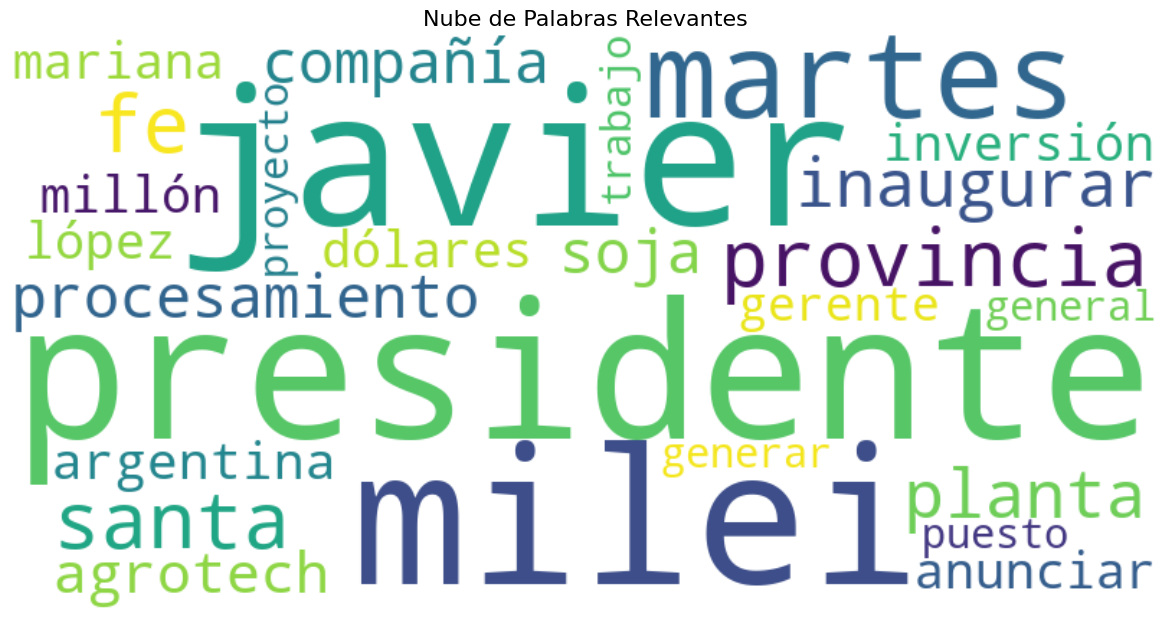

In [35]:
print("=== NUBE DE PALABRAS ===")
crear_nube_palabras(analizador_prueba.doc)


=== ENTIDADES MAS COMUNES ===


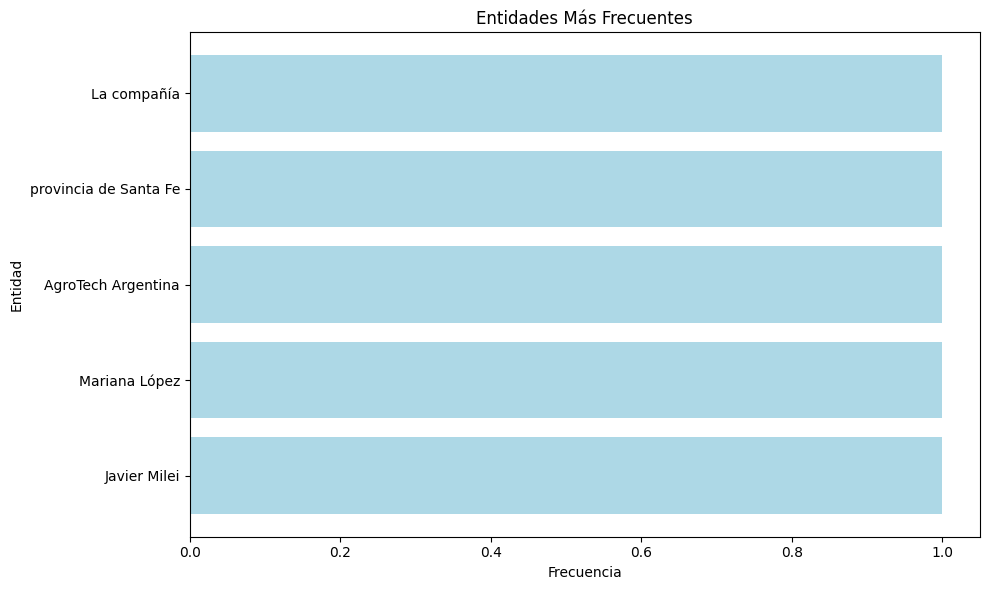

In [47]:
print("\n=== ENTIDADES MAS COMUNES ===")
entidades = analizador_prueba.obtener_entidades()
visualizar_entidades_mas_comunes(entidades)

## Parte 4: integración en un pipeline (10 minutos)

**Objetivo:** integrar extracción, análisis y reporte agregado para varias noticias.

En esta parte conviene trabajar de menor a mayor:
1. probá con una sola URL;
2. verificá que el texto se extraiga;
3. recién después procesa una lista.


Iniciando procesamiento de 3 URLs...
Procesada: https://www.lanacion.com.ar/politica/una-advertencia-que-sacudio-al-gobierno-nid18042026/
Procesada: https://www.lanacion.com.ar/deportes/futbol/superclasico-los-puntajes-de-river-nid19042026/
Procesada: https://www.lanacion.com.ar/deportes/futbol/los-festejos-intimos-de-boca-en-el-monumental-tras-la-victoria-sobre-river-por-1-a-0-nid19042026/
Procesamiento completado.

--- REPORTE AGREGADO DE 3 NOTICIAS ---

--- ENTIDADES MAS COMUNES ---


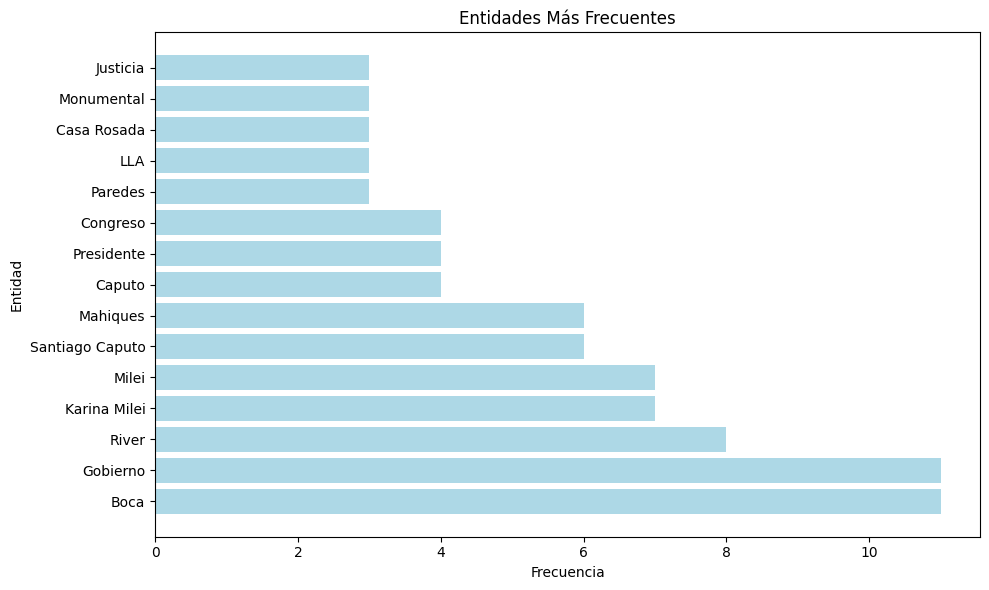


--- VERBOS MAS COMUNES ---
[('tener', 2), ('hacer', 2), ('estar', 2), ('venir', 2), ('dar', 2), ('ganar', 2), ('generar', 1), ('ocurrir', 1), ('hablar', 1), ('interpretar', 1), ('cerrar', 1), ('llevar', 1), ('empezar', 1), ('entender', 1), ('reanimar', 1)]
  tener: 2
  hacer: 2
  estar: 2
  venir: 2
  dar: 2
  ganar: 2
  generar: 1
  ocurrir: 1
  hablar: 1
  interpretar: 1
  cerrar: 1
  llevar: 1
  empezar: 1
  entender: 1
  reanimar: 1


In [48]:
class AnalizadorTendencias:
    def __init__(self, lista_urls):
        self.urls = lista_urls
        self.noticias_data = []
        self.analizadores = []
        self.nlp = spacy.load("es_core_news_lg")

    def procesar_todas(self):
        """Orquesta la extracción y el análisis de todas las URLs."""
        print(f"Iniciando procesamiento de {len(self.urls)} URLs...")
        for url in self.urls:
            # PASO 11: usa extraer_noticia(url).
            noticia = extraer_noticia(url)

            if noticia:
                self.noticias_data.append(noticia)

                # PASO 12: crea un AnalizadorNoticia y guardalo en self.analizadores.

                analizador = AnalizadorNoticia(noticia['texto'], self.nlp)
                self.analizadores.append(analizador)
                print(f"Procesada: {url}")
            else:
                print(f"Fallo al procesar: {url}")

        print("Procesamiento completado.")

    def generar_reporte_agregado(self, n=15):
        """Genera un reporte consolidado de todas las noticias procesadas."""
        if not self.analizadores:
            print("No hay noticias procesadas para generar un reporte.")
            return

        todas_las_entidades = {
            "PERSONAS": [],
            "ORGANIZACIONES": [],
            "LUGARES": [],
            "OTROS": []
        }
        todos_los_verbos = []

        # PASO 13: recorre self.analizadores y acumula entidades y verbos.

        for analizador in self.analizadores:
            # Obtener entidades de cada noticia
            entidades = analizador.obtener_entidades()
            for categoria, lista_ent in entidades.items():
                todas_las_entidades[categoria].extend(lista_ent)
            
            # Obtener verbos de cada noticia
            verbos_tuplas = analizador.obtener_verbos_principales(n=50)
            for verbo, freq in verbos_tuplas:
                todos_los_verbos.append(verbo)

        print(f"\n--- REPORTE AGREGADO DE {len(self.analizadores)} NOTICIAS ---")
        print("\n--- ENTIDADES MAS COMUNES ---")
        visualizar_entidades_mas_comunes(todas_las_entidades, n=n)

        print("\n--- VERBOS MAS COMUNES ---")
        frecuencias_verbos = Counter(todos_los_verbos)
        print(frecuencias_verbos.most_common(n))
        for verbo, freq in frecuencias_verbos.most_common(n):
            print(f"  {verbo}: {freq}")


# Descomenta cuando completes la mayor parte del laboratorio.
pipeline = AnalizadorTendencias(urls_noticias)
pipeline.procesar_todas()
pipeline.generar_reporte_agregado()


## Bitacora de chat con agente de IA y pasos recomendados:

Elegí Trafilatura sobre BeautifulSoup para la extracción de noticias porque es más específico para contenido periodístico y ya estaba en las dependencias instaladas (decisión tomada por consejo del agente)

Para clasificar entidades, adopté un diccionario de 4 categorías (PER, ORG, LOC, OTROS) en lugar de listas anidadas porque ofrece mejor estructura para iterar y visualizar después. La lematización de verbos con token.lemma_ + Counter normaliza flexiones verbales evitando duplicados falsos como "corriendo" y "correr".

En visualizaciones, prioricé Matplotlib sobre Plotly para Parte 3 porque evita dependencias extras (nbformat) y la sintaxis es más directa.

## Entregables, criterios de evaluación y cierre

### Entregables sugeridos
- Las funciones y clases completadas.
- Al menos una prueba con una noticia real.
- Una bitácora breve de interacción con IA.
- Una justificación corta sobre una decisión que tomaste a partir de una sugerencia de la IA y otra que descartaste.

### Criterios de evaluación
- **Funcionamiento técnico:** que el pipeline complete tareas básicas de extracción, análisis y visualización.
- **Juicio crítico:** que puedas explicar por qué elegiste una estrategia y no otra.
- **Uso de IA con criterio:** que la IA aparezca como apoyo de exploración, no como reemplazo del razonamiento.
- **Proceso documentado:** que la bitácora muestre qué tomaste, qué corregiste y qué descartaste.
- **Claridad del código:** que las funciones y clases sean legibles y consistentes.

### Checklist antes de entregar
- Probaste cada parte por separado antes de integrar todo?
- Podés explicar qué hace cada función principal?
- Tu bitácora muestra intervención humana real sobre los outputs de IA?
- Hay al menos un ejemplo donde corregiste o descartaste una sugerencia de la IA?

Si respondiste que sí a estas preguntas, tu laboratorio ya está alineado con la propuesta pedagógica de la cátedra.
